100%|██████████| 170M/170M [01:41<00:00, 1.68MB/s]


Epoch 1/10 | Loss: 1.6975 | Accuracy: 40.38%
Epoch 2/10 | Loss: 1.4805 | Accuracy: 48.21%
Epoch 3/10 | Loss: 1.3866 | Accuracy: 51.53%
Epoch 4/10 | Loss: 1.3154 | Accuracy: 54.31%
Epoch 5/10 | Loss: 1.2563 | Accuracy: 56.10%
Epoch 6/10 | Loss: 1.2106 | Accuracy: 58.07%
Epoch 7/10 | Loss: 1.1614 | Accuracy: 59.67%
Epoch 8/10 | Loss: 1.1200 | Accuracy: 61.18%
Epoch 9/10 | Loss: 1.0815 | Accuracy: 62.60%
Epoch 10/10 | Loss: 1.0414 | Accuracy: 63.98%
Epoch 1/10 | Loss: 1.6400 | Accuracy: 42.52%
Epoch 2/10 | Loss: 1.4415 | Accuracy: 49.72%
Epoch 3/10 | Loss: 1.3500 | Accuracy: 52.92%
Epoch 4/10 | Loss: 1.2746 | Accuracy: 55.80%
Epoch 5/10 | Loss: 1.2171 | Accuracy: 57.73%
Epoch 6/10 | Loss: 1.1643 | Accuracy: 59.74%
Epoch 7/10 | Loss: 1.1081 | Accuracy: 61.73%
Epoch 8/10 | Loss: 1.0607 | Accuracy: 63.13%
Epoch 9/10 | Loss: 1.0175 | Accuracy: 64.90%
Epoch 10/10 | Loss: 0.9800 | Accuracy: 66.25%


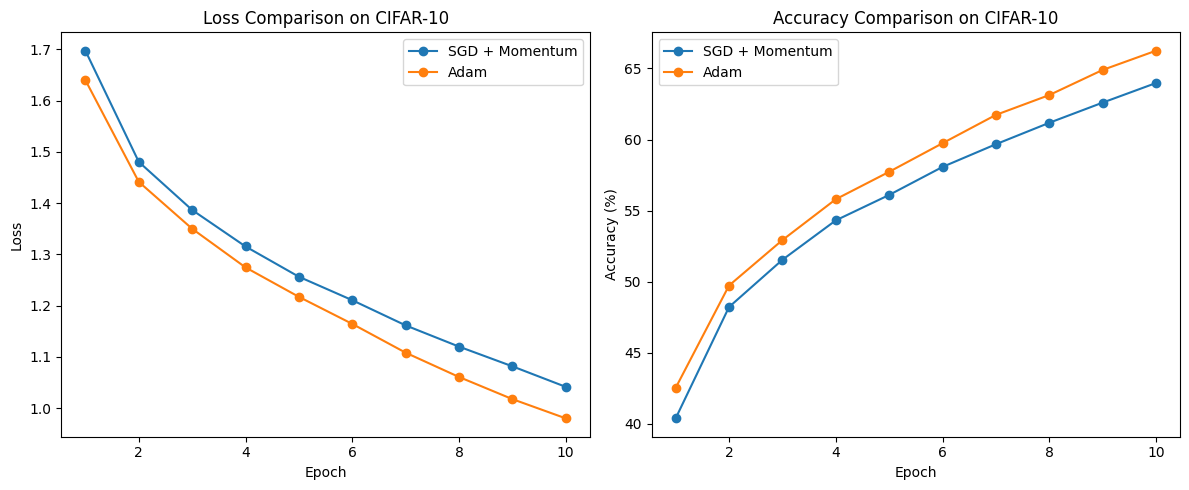


Final Comparison
SGD + Momentum - Loss: 1.0414, Accuracy: 63.98%
Adam           - Loss: 0.9800, Accuracy: 66.25%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(self.flatten(x))

def train(model, optimizer, epochs=10):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    accuracies = []

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        model.train()

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predictions = outputs.argmax(1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(f"Epoch {epoch + 1}/10 | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

    return losses, accuracies

model_sgd = MLP()
sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
losses_sgd, acc_sgd = train(model_sgd, sgd)

model_adam = MLP()
adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, acc_adam = train(model_adam, adam)

epochs = range(1, 11)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, losses_sgd, marker="o", label="SGD + Momentum")
plt.plot(epochs, losses_adam, marker="o", label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, acc_sgd, marker="o", label="SGD + Momentum")
plt.plot(epochs, acc_adam, marker="o", label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10")
plt.legend()

plt.tight_layout()
plt.show()

print("\nFinal Comparison")
print(f"SGD + Momentum - Loss: {losses_sgd[-1]:.4f}, Accuracy: {acc_sgd[-1]:.2f}%")
print(f"Adam           - Loss: {losses_adam[-1]:.4f}, Accuracy: {acc_adam[-1]:.2f}%")